![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)
# Training EfficienetB0
![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

#### EFFICIENTNET DATASET DISTRIBUTION

In [ ]:
from pathlib import Path

dataset_path = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Data_Clean"
)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 65)
print("EFFICIENTNET DATASET DISTRIBUTION")
print("=" * 65)

grand_total = 0

for class_folder in sorted(dataset_path.iterdir()):
    if not class_folder.is_dir():
        continue

    count = sum(
        1
        for file in class_folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    )

    grand_total += count
    print(f"{class_folder.name:<20}: {count}")

print("-" * 65)
print(f"{'GRAND TOTAL':<20}: {grand_total}")
print("=" * 65)

EFFICIENTNET DATASET DISTRIBUTION
Healthy             : 2226
Nitrogen            : 296
Phosphorus          : 429
Potassium           : 318
-----------------------------------------------------------------
GRAND TOTAL         : 3269


In [ ]:
from pathlib import Path

dataset_path = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Data_Clean"
)

print("=" * 70)
print("CLASSIFICATION DATASET STRUCTURE")
print("=" * 70)

for folder in sorted(dataset_path.iterdir()):

    if not folder.is_dir():
        continue

    image_count = sum(
        1
        for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in {
            ".jpg", ".jpeg", ".png", ".bmp", ".webp"
        }
    )

    print(f"📁 {folder.name:<20} → {image_count} images")

print("=" * 70)

CLASSIFICATION DATASET STRUCTURE
📁 Healthy              → 2226 images
📁 Nitrogen             → 296 images
📁 Phosphorus           → 429 images
📁 Potassium            → 318 images


![separator1](https://i.imgur.com/ZUWYTii.png)
### Split Dataset 70/15/15
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil
import random

# ============================================================
# PATHS
# ============================================================

SOURCE_DIR = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Data_Clean"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Split"
)

# ============================================================
# SETTINGS
# ============================================================

SEED = 42

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

CLASSES = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]

# ============================================================
# CREATE OUTPUT FOLDERS
# ============================================================

for split in ["train", "val", "test"]:
    for class_name in CLASSES:
        (OUTPUT_DIR / split / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

# ============================================================
# SPLIT DATASET
# ============================================================

print("=" * 70)
print("CREATING CLEAN 70 / 15 / 15 DATASET SPLIT")
print("=" * 70)

for class_name in CLASSES:

    class_dir = SOURCE_DIR / class_name

    images = [
        file
        for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Reproducible shuffle
    rng = random.Random(SEED)
    rng.shuffle(images)

    # --------------------------------------------------------
    # 70% TRAIN / 30% TEMPORARY
    # --------------------------------------------------------

    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=SEED
    )

    # --------------------------------------------------------
    # 15% VALIDATION / 15% TEST
    # --------------------------------------------------------

    val_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=SEED
    )

    # --------------------------------------------------------
    # COPY TRAIN
    # --------------------------------------------------------

    for image in train_images:
        shutil.copy2(
            image,
            OUTPUT_DIR / "train" / class_name / image.name
        )

    # --------------------------------------------------------
    # COPY VALIDATION
    # --------------------------------------------------------

    for image in val_images:
        shutil.copy2(
            image,
            OUTPUT_DIR / "val" / class_name / image.name
        )

    # --------------------------------------------------------
    # COPY TEST
    # --------------------------------------------------------

    for image in test_images:
        shutil.copy2(
            image,
            OUTPUT_DIR / "test" / class_name / image.name
        )

    print(
        f"{class_name:<15} "
        f"Train: {len(train_images):>4} | "
        f"Val: {len(val_images):>4} | "
        f"Test: {len(test_images):>4}"
    )

# ============================================================
# VERIFY FINAL DATASET
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET VERIFICATION")
print("=" * 70)

grand_total = 0

for split in ["train", "val", "test"]:

    split_total = 0

    print(f"\n{split.upper()}")

    for class_name in CLASSES:

        folder = OUTPUT_DIR / split / class_name

        count = sum(
            1
            for file in folder.iterdir()
            if file.is_file()
            and file.suffix.lower() in IMAGE_EXTENSIONS
        )

        split_total += count

        print(f"  {class_name:<15}: {count}")

    grand_total += split_total

    print(f"  {'TOTAL':<15}: {split_total}")

# ============================================================
# TOTAL CHECK
# ============================================================

print("\n" + "-" * 70)
print(f"GRAND TOTAL: {grand_total}")
print("-" * 70)

if grand_total == 3269:
    print("✅ VERIFIED: Total is exactly 3,269 images.")
else:
    print(
        f"⚠️ WARNING: Expected 3,269 images, "
        f"but found {grand_total}."
    )

print("=" * 70)

print("\nOutput folder:")
print(OUTPUT_DIR)

CREATING CLEAN 70 / 15 / 15 DATASET SPLIT
Healthy         Train: 1558 | Val:  334 | Test:  334
Nitrogen        Train:  207 | Val:   44 | Test:   45
Phosphorus      Train:  300 | Val:   64 | Test:   65
Potassium       Train:  222 | Val:   48 | Test:   48

FINAL DATASET VERIFICATION

TRAIN
  Healthy        : 1558
  Nitrogen       : 207
  Phosphorus     : 300
  Potassium      : 222
  TOTAL          : 2287

VAL
  Healthy        : 334
  Nitrogen       : 44
  Phosphorus     : 64
  Potassium      : 48
  TOTAL          : 490

TEST
  Healthy        : 334
  Nitrogen       : 45
  Phosphorus     : 65
  Potassium      : 48
  TOTAL          : 492

----------------------------------------------------------------------
GRAND TOTAL: 3269
----------------------------------------------------------------------
✅ VERIFIED: Total is exactly 3,269 images.

Output folder:
/content/drive/MyDrive/CornLeafTraining/Classification_Split


![separator1](https://i.imgur.com/ZUWYTii.png)
BALANCING TRAIN DATA
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
from pathlib import Path
from PIL import Image, ImageEnhance
import random
import shutil

# ============================================================
# PATHS
# ============================================================

TRAIN_DIR = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Split/train"
)

BALANCED_DIR = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced"
)

# ============================================================
# SETTINGS
# ============================================================

TARGET_COUNT = 1558
SEED = 42

random.seed(SEED)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

CLASSES = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]

# ============================================================
# CLEAN OUTPUT DIRECTORY IF IT ALREADY EXISTS
# ============================================================

if BALANCED_DIR.exists():
    shutil.rmtree(BALANCED_DIR)
    print("🗑️ Existing balanced dataset removed.")

# Create output folders
for class_name in CLASSES:
    (BALANCED_DIR / class_name).mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# AUGMENTATION FUNCTION
# ============================================================

def augment_image(image):

    # --------------------------------------------------------
    # Horizontal flip
    # --------------------------------------------------------

    if random.random() < 0.5:
        image = image.transpose(
            Image.Transpose.FLIP_LEFT_RIGHT
        )

    # --------------------------------------------------------
    # Small rotation
    # --------------------------------------------------------

    angle = random.uniform(-15, 15)

    image = image.rotate(
        angle,
        resample=Image.Resampling.BILINEAR,
        expand=False
    )

    # --------------------------------------------------------
    # Brightness
    # --------------------------------------------------------

    if random.random() < 0.5:

        brightness_factor = random.uniform(
            0.85,
            1.15
        )

        image = ImageEnhance.Brightness(
            image
        ).enhance(
            brightness_factor
        )

    # --------------------------------------------------------
    # Contrast
    # --------------------------------------------------------

    if random.random() < 0.5:

        contrast_factor = random.uniform(
            0.85,
            1.15
        )

        image = ImageEnhance.Contrast(
            image
        ).enhance(
            contrast_factor
        )

    # --------------------------------------------------------
    # Color / Saturation
    # --------------------------------------------------------

    if random.random() < 0.5:

        color_factor = random.uniform(
            0.85,
            1.15
        )

        image = ImageEnhance.Color(
            image
        ).enhance(
            color_factor
        )

    # --------------------------------------------------------
    # Slight random crop / zoom
    # --------------------------------------------------------

    if random.random() < 0.4:

        width, height = image.size

        crop_scale = random.uniform(
            0.85,
            1.0
        )

        crop_width = int(
            width * crop_scale
        )

        crop_height = int(
            height * crop_scale
        )

        if (
            crop_width > 0
            and crop_height > 0
            and crop_width <= width
            and crop_height <= height
        ):

            left = random.randint(
                0,
                width - crop_width
            )

            top = random.randint(
                0,
                height - crop_height
            )

            image = image.crop(
                (
                    left,
                    top,
                    left + crop_width,
                    top + crop_height
                )
            )

            image = image.resize(
                (width, height),
                Image.Resampling.BILINEAR
            )

    return image


# ============================================================
# PROCESS EACH CLASS
# ============================================================

print("=" * 70)
print("BALANCING TRAINING DATASET")
print("=" * 70)

for class_name in CLASSES:

    source_dir = TRAIN_DIR / class_name
    output_dir = BALANCED_DIR / class_name

    # --------------------------------------------------------
    # Get original images
    # --------------------------------------------------------

    images = [
        file
        for file in source_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    original_count = len(images)

    print(f"\n{class_name}")
    print(f"Original images : {original_count}")
    print(f"Target images   : {TARGET_COUNT}")

    # --------------------------------------------------------
    # Copy original images
    # --------------------------------------------------------

    for image_path in images:

        destination = output_dir / image_path.name

        shutil.copy2(
            image_path,
            destination
        )

    # --------------------------------------------------------
    # Calculate number of augmented images
    # --------------------------------------------------------

    images_needed = TARGET_COUNT - original_count

    print(
        f"Augmented images needed: "
        f"{max(images_needed, 0)}"
    )

    # --------------------------------------------------------
    # Generate augmented images
    # --------------------------------------------------------

    for i in range(max(images_needed, 0)):

        # Randomly select an original image
        source_image_path = random.choice(images)

        # Open image
        image = Image.open(
            source_image_path
        ).convert("RGB")

        # Apply augmentation
        augmented_image = augment_image(
            image
        )

        # Save augmented image
        output_path = output_dir / (
            f"aug_{i:05d}_"
            f"{source_image_path.stem}.jpg"
        )

        augmented_image.save(
            output_path,
            format="JPEG",
            quality=95
        )

    print(
        f"✅ {class_name} completed"
    )


# ============================================================
# VERIFY BALANCED DATASET
# ============================================================

print("\n" + "=" * 70)
print("BALANCED DATASET VERIFICATION")
print("=" * 70)

grand_total = 0

for class_name in CLASSES:

    folder = BALANCED_DIR / class_name

    count = sum(
        1
        for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    )

    grand_total += count

    print(
        f"{class_name:<15}: {count}"
    )

print("-" * 70)
print(
    f"{'GRAND TOTAL':<15}: "
    f"{grand_total}"
)
print("=" * 70)

if grand_total == 6232:
    print(
        "✅ SUCCESS: Training dataset is perfectly balanced!"
    )
else:
    print(
        f"⚠️ Expected 6232 images, "
        f"but found {grand_total}."
    )

print("\nBalanced dataset:")
print(BALANCED_DIR)

BALANCING TRAINING DATASET

Healthy
Original images : 1558
Target images   : 1558
Augmented images needed: 0
✅ Healthy completed

Nitrogen
Original images : 207
Target images   : 1558
Augmented images needed: 1351
✅ Nitrogen completed

Phosphorus
Original images : 300
Target images   : 1558
Augmented images needed: 1258
✅ Phosphorus completed

Potassium
Original images : 222
Target images   : 1558
Augmented images needed: 1336
✅ Potassium completed

BALANCED DATASET VERIFICATION
Healthy        : 1558
Nitrogen       : 1558
Phosphorus     : 1558
Potassium      : 1558
----------------------------------------------------------------------
GRAND TOTAL    : 6232
✅ SUCCESS: Training dataset is perfectly balanced!

Balanced dataset:
/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced


#### TRAINING DATASET STRUCTURE

In [ ]:
from pathlib import Path

DATASET = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced"
)

print("=" * 60)
print("TRAINING DATASET STRUCTURE")
print("=" * 60)

if not DATASET.exists():
    print("❌ Dataset folder not found!")
else:
    print(f"✅ Dataset found:\n{DATASET}\n")

    for class_folder in sorted(DATASET.iterdir()):
        if class_folder.is_dir():

            images = [
                p for p in class_folder.iterdir()
                if p.is_file()
                and p.suffix.lower() in {
                    ".jpg", ".jpeg", ".png",
                    ".bmp", ".webp"
                }
            ]

            print(f"📁 {class_folder.name}")
            print(f"   Images: {len(images)}")

    print("\n" + "=" * 60)
    print("EXPECTED")
    print("=" * 60)
    print("Healthy      : 1558")
    print("Nitrogen     : 1558")
    print("Phosphorus   : 1558")
    print("Potassium    : 1558")
    print("TOTAL        : 6232")

TRAINING DATASET STRUCTURE
✅ Dataset found:
/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced

📁 Healthy
   Images: 1558
📁 Nitrogen
   Images: 1558
📁 Phosphorus
   Images: 1558
📁 Potassium
   Images: 1558

EXPECTED
Healthy      : 1558
Nitrogen     : 1558
Phosphorus   : 1558
Potassium    : 1558
TOTAL        : 6232


![separator1](https://i.imgur.com/ZUWYTii.png)
Resize Train Data to 224 x 224
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
import shutil

# ============================================================
# PATHS
# ============================================================

SOURCE_DIR = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced_resize224x224px"
)

TARGET_SIZE = 224

CLASSES = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}


# ============================================================
# CHECK SOURCE
# ============================================================

if not SOURCE_DIR.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{SOURCE_DIR}"
    )

print("✅ Source dataset found:")
print(SOURCE_DIR)


# ============================================================
# REMOVE OLD OUTPUT IF IT EXISTS
# ============================================================

if OUTPUT_DIR.exists():
    print("\n⚠️ Existing output folder found.")
    print("Removing old output...")
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# GET PADDING COLOR FROM IMAGE EDGES
# ============================================================

def get_edge_color(image):
    """
    Gets a representative RGB color from the
    outer edges of the image.

    Median is used to reduce the effect of
    extreme bright/dark pixels.
    """

    img = np.array(image.convert("RGB"))

    top = img[0, :, :]
    bottom = img[-1, :, :]
    left = img[:, 0, :]
    right = img[:, -1, :]

    edge_pixels = np.concatenate(
        [top, bottom, left, right],
        axis=0
    )

    median_color = np.median(
        edge_pixels,
        axis=0
    )

    return tuple(
        median_color.astype(np.uint8)
    )


# ============================================================
# RESIZE + MINIMUM PADDING
# ============================================================

def resize_with_padding(image, target_size=224):
    """
    Resizes the image while preserving its
    original aspect ratio.

    No stretching.
    No cropping.

    Only the required padding is added
    to reach target_size x target_size.
    """

    image = image.convert("RGB")

    original_width, original_height = image.size

    # --------------------------------------------------------
    # Calculate proportional resize
    # --------------------------------------------------------

    scale = min(
        target_size / original_width,
        target_size / original_height
    )

    new_width = max(
        1,
        round(original_width * scale)
    )

    new_height = max(
        1,
        round(original_height * scale)
    )

    # --------------------------------------------------------
    # Resize while preserving aspect ratio
    # --------------------------------------------------------

    resized = image.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # --------------------------------------------------------
    # Get padding color from image edges
    # --------------------------------------------------------

    padding_color = get_edge_color(image)

    # --------------------------------------------------------
    # Create final 224 x 224 canvas
    # --------------------------------------------------------

    canvas = Image.new(
        "RGB",
        (target_size, target_size),
        padding_color
    )

    # --------------------------------------------------------
    # Center the resized image
    # --------------------------------------------------------

    x_offset = (
        target_size - new_width
    ) // 2

    y_offset = (
        target_size - new_height
    ) // 2

    canvas.paste(
        resized,
        (x_offset, y_offset)
    )

    return canvas


# ============================================================
# PROCESS EACH CLASS
# ============================================================

total_processed = 0
total_errors = 0

print("\n" + "=" * 65)
print("STARTING 224 × 224 PREPROCESSING")
print("=" * 65)

for class_name in CLASSES:

    source_class = SOURCE_DIR / class_name
    output_class = OUTPUT_DIR / class_name

    output_class.mkdir(
        parents=True,
        exist_ok=True
    )

    images = [
        p for p in source_class.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    processed = 0
    errors = 0

    print(f"\n📁 {class_name}")
    print(f"   Source images: {len(images)}")

    for image_path in images:

        try:

            with Image.open(image_path) as image:

                processed_image = resize_with_padding(
                    image,
                    TARGET_SIZE
                )

                # Save as JPEG
                output_path = (
                    output_class /
                    f"{image_path.stem}.jpg"
                )

                processed_image.save(
                    output_path,
                    "JPEG",
                    quality=95
                )

                processed += 1

        except Exception as e:

            errors += 1
            total_errors += 1

            print(
                f"   ⚠️ Error: {image_path.name}"
            )
            print(
                f"      {e}"
            )

    total_processed += processed

    print(f"   ✅ Processed: {processed}")

    if errors > 0:
        print(f"   ⚠️ Errors: {errors}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("PREPROCESSING COMPLETE")
print("=" * 65)

print(f"Total processed : {total_processed}")
print(f"Total errors    : {total_errors}")

print("\nExpected:")
print("Total images    : 6232")

print("\nOutput folder:")
print(OUTPUT_DIR)

✅ Source dataset found:
/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced

STARTING 224 × 224 PREPROCESSING

📁 Healthy
   Source images: 1558
   ✅ Processed: 1558

📁 Nitrogen
   Source images: 1558
   ✅ Processed: 1558

📁 Phosphorus
   Source images: 1558
   ✅ Processed: 1558

📁 Potassium
   Source images: 1558
   ✅ Processed: 1558

PREPROCESSING COMPLETE
Total processed : 6232
Total errors    : 0

Expected:
Total images    : 6232

Output folder:
/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced_resize224x224px


![separator1](https://i.imgur.com/ZUWYTii.png)
Resize Val Data to 224 x 224
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
from PIL import Image
import os
import numpy as np

# ============================================================
# PATHS
# ============================================================

SOURCE_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Split/val"

OUTPUT_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Val_resize224x224px"

TARGET_SIZE = 224


# ============================================================
# GET PADDING COLOR FROM IMAGE EDGES
# ============================================================

def get_edge_color(img):
    img_array = np.array(img)

    top = img_array[0, :, :]
    bottom = img_array[-1, :, :]
    left = img_array[:, 0, :]
    right = img_array[:, -1, :]

    edges = np.concatenate([top, bottom, left, right], axis=0)

    edge_color = np.median(edges, axis=0).astype(np.uint8)

    return tuple(edge_color)


# ============================================================
# RESIZE WITH ASPECT RATIO + MINIMUM PADDING
# ============================================================

def resize_with_padding(img, target_size=224):

    original_width, original_height = img.size

    # Preserve aspect ratio
    scale = min(
        target_size / original_width,
        target_size / original_height
    )

    new_width = int(original_width * scale)
    new_height = int(original_height * scale)

    # Resize
    resized_img = img.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # Get padding color from image edges
    padding_color = get_edge_color(img)

    # Create 224x224 canvas
    canvas = Image.new(
        "RGB",
        (target_size, target_size),
        padding_color
    )

    # Center resized image
    paste_x = (target_size - new_width) // 2
    paste_y = (target_size - new_height) // 2

    canvas.paste(
        resized_img,
        (paste_x, paste_y)
    )

    return canvas


# ============================================================
# PROCESS VALIDATION DATASET
# ============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

total_processed = 0
total_errors = 0

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for class_name in sorted(os.listdir(SOURCE_DIR)):

    source_class_dir = os.path.join(SOURCE_DIR, class_name)
    output_class_dir = os.path.join(OUTPUT_DIR, class_name)

    if not os.path.isdir(source_class_dir):
        continue

    os.makedirs(output_class_dir, exist_ok=True)

    class_processed = 0

    for filename in os.listdir(source_class_dir):

        if not filename.lower().endswith(valid_extensions):
            continue

        source_path = os.path.join(source_class_dir, filename)

        try:
            # Open image
            img = Image.open(source_path).convert("RGB")

            # Resize + padding
            processed_img = resize_with_padding(
                img,
                TARGET_SIZE
            )

            # Save as JPEG
            output_filename = os.path.splitext(filename)[0] + ".jpg"
            output_path = os.path.join(
                output_class_dir,
                output_filename
            )

            processed_img.save(
                output_path,
                "JPEG",
                quality=95
            )

            class_processed += 1
            total_processed += 1

        except Exception as e:
            total_errors += 1
            print(f"ERROR: {source_path}")
            print(e)

    print(f"{class_name:12s}: {class_processed} processed")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 50)
print("VALIDATION RESIZE COMPLETE")
print("=" * 50)

print(f"Total processed : {total_processed}")
print(f"Total errors    : {total_errors}")
print(f"Output folder   : {OUTPUT_DIR}")
print(f"Image size      : {TARGET_SIZE} x {TARGET_SIZE}")

Healthy     : 334 processed
Nitrogen    : 44 processed
Phosphorus  : 64 processed
Potassium   : 48 processed

VALIDATION RESIZE COMPLETE
Total processed : 490
Total errors    : 0
Output folder   : /content/drive/MyDrive/CornLeafTraining/Classification_Val_resize224x224px
Image size      : 224 x 224


![separator1](https://i.imgur.com/ZUWYTii.png)
Resize Test Data to 224 x 224
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
from PIL import Image
import os
import numpy as np

# ============================================================
# PATHS
# ============================================================

SOURCE_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Split/test"

OUTPUT_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Test_resize224x224px"

TARGET_SIZE = 224


# ============================================================
# GET PADDING COLOR FROM IMAGE EDGES
# ============================================================

def get_edge_color(img):
    img_array = np.array(img)

    top = img_array[0, :, :]
    bottom = img_array[-1, :, :]
    left = img_array[:, 0, :]
    right = img_array[:, -1, :]

    edges = np.concatenate(
        [top, bottom, left, right],
        axis=0
    )

    edge_color = np.median(edges, axis=0).astype(np.uint8)

    return tuple(edge_color)


# ============================================================
# RESIZE WITH ASPECT RATIO + MINIMUM PADDING
# ============================================================

def resize_with_padding(img, target_size=224):

    original_width, original_height = img.size

    # Preserve aspect ratio
    scale = min(
        target_size / original_width,
        target_size / original_height
    )

    new_width = int(original_width * scale)
    new_height = int(original_height * scale)

    # Resize without stretching
    resized_img = img.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # Get padding color from image edges
    padding_color = get_edge_color(img)

    # Create final 224x224 canvas
    canvas = Image.new(
        "RGB",
        (target_size, target_size),
        padding_color
    )

    # Center resized image
    paste_x = (target_size - new_width) // 2
    paste_y = (target_size - new_height) // 2

    canvas.paste(
        resized_img,
        (paste_x, paste_y)
    )

    return canvas


# ============================================================
# PROCESS TEST DATASET
# ============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

total_processed = 0
total_errors = 0

valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

for class_name in sorted(os.listdir(SOURCE_DIR)):

    source_class_dir = os.path.join(
        SOURCE_DIR,
        class_name
    )

    output_class_dir = os.path.join(
        OUTPUT_DIR,
        class_name
    )

    if not os.path.isdir(source_class_dir):
        continue

    os.makedirs(
        output_class_dir,
        exist_ok=True
    )

    class_processed = 0

    for filename in os.listdir(source_class_dir):

        if not filename.lower().endswith(valid_extensions):
            continue

        source_path = os.path.join(
            source_class_dir,
            filename
        )

        try:
            # Open image
            img = Image.open(source_path).convert("RGB")

            # Resize + padding
            processed_img = resize_with_padding(
                img,
                TARGET_SIZE
            )

            # Save as JPEG
            output_filename = (
                os.path.splitext(filename)[0] + ".jpg"
            )

            output_path = os.path.join(
                output_class_dir,
                output_filename
            )

            processed_img.save(
                output_path,
                "JPEG",
                quality=95
            )

            class_processed += 1
            total_processed += 1

        except Exception as e:

            total_errors += 1

            print(f"ERROR: {source_path}")
            print(e)

    print(
        f"{class_name:12s}: "
        f"{class_processed} processed"
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 50)
print("TEST RESIZE COMPLETE")
print("=" * 50)

print(f"Total processed : {total_processed}")
print(f"Total errors    : {total_errors}")
print(f"Output folder   : {OUTPUT_DIR}")
print(f"Image size      : {TARGET_SIZE} x {TARGET_SIZE}")

Healthy     : 334 processed
Nitrogen    : 45 processed
Phosphorus  : 65 processed
Potassium   : 48 processed

TEST RESIZE COMPLETE
Total processed : 492
Total errors    : 0
Output folder   : /content/drive/MyDrive/CornLeafTraining/Classification_Test_resize224x224px
Image size      : 224 x 224


### Check Gpu is available

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available!")
else:
    print("❌ GPU is NOT available.")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU is available!


![separator1](https://i.imgur.com/ZUWYTii.png)
Data Loader
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
import tensorflow as tf

# ============================================================
# DATASET PATHS
# ============================================================

TRAIN_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Train_Balanced_resize224x224px"

VAL_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Val_resize224x224px"

TEST_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Test_resize224x224px"


# ============================================================
# SETTINGS
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


# ============================================================
# LOAD DATASETS
# ============================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# DISPLAY INFORMATION
# ============================================================

print("\nClass names:")
print(train_dataset.class_names)

print("\nNumber of classes:", len(train_dataset.class_names))

print("\nDatasets loaded successfully! ✅")

Found 6232 files belonging to 4 classes.
Found 490 files belonging to 4 classes.
Found 492 files belonging to 4 classes.

Class names:
['Healthy', 'Nitrogen', 'Phosphorus', 'Potassium']

Number of classes: 4

Datasets loaded successfully! ✅


![separator1](https://i.imgur.com/ZUWYTii.png)
Build EfficientNet-B0
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# ============================================================
# MODEL SETTINGS
# ============================================================

NUM_CLASSES = 4

# ============================================================
# LOAD PRETRAINED EFFICIENTNET-B0
# ============================================================

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained backbone
base_model.trainable = False


# ============================================================
# BUILD CLASSIFICATION MODEL
# ============================================================

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# DISPLAY MODEL INFORMATION
# ============================================================

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

![separator1](https://i.imgur.com/ZUWYTii.png)
Compile the Model
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully! ✅")

Model compiled successfully! ✅


![separator1](https://i.imgur.com/ZUWYTii.png)
Callbacks
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
# ============================================================
# CALLBACKS
# ============================================================

callbacks_initial = [

    # Save the model with the best validation loss
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/CornLeafTraining/efficientnetb0_initial_best.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    # Stop training if validation loss stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

print("Callbacks ready! ✅")

Callbacks ready! ✅


![separator1](https://i.imgur.com/ZUWYTii.png)
## Start Training
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
# ============================================================
# TRAINING
# ============================================================

INITIAL_EPOCHS = 30

history_initial = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_initial
)

Epoch 1/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5782 - loss: 1.0350
Epoch 1: val_loss improved from None to 0.56198, saving model to /content/drive/MyDrive/CornLeafTraining/efficientnetb0_initial_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CornLeafTraining/efficientnetb0_initial_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 1179s 6s/step - accuracy: 0.6958 - loss: 0.8203 - val_accuracy: 0.8184 - val_loss: 0.5620 - learning_rate: 0.0010
Epoch 2/30
194/195 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7995 - loss: 0.5775
Epoch 2: val_loss improved from 0.56198 to 0.47729, saving model to /content/drive/MyDrive/CornLeafTraining/efficientnetb0_initial_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CornLeafTraining/efficientnetb0_initial_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.8095 - loss: 0.5500 - val_accuracy: 0.8347 - val_loss: 0.4773 - learning_rate: 0.0010
Epoch 3/30
194/195 ━━━━━━━━━━━━━━━━━━━━ 0s 

![separator1](https://i.imgur.com/ZUWYTii.png)
###PLot Training history
![separator1](https://i.imgur.com/ZUWYTii.png)

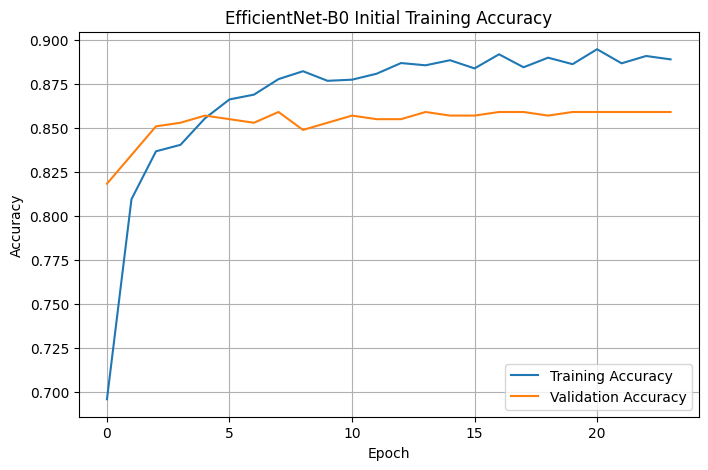

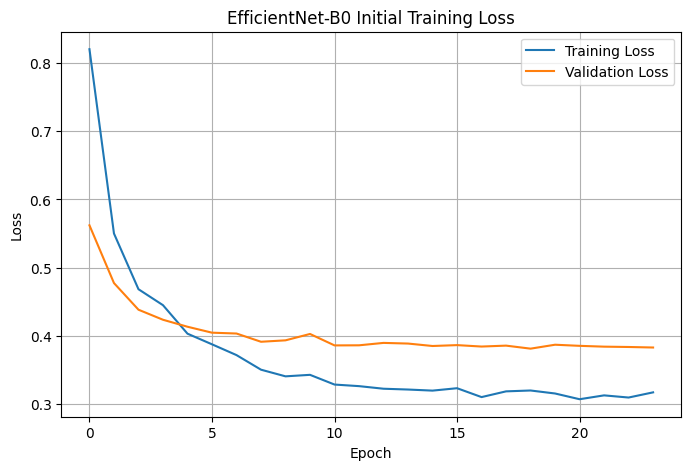

In [ ]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. TRAINING
# ------------------------------------------------------------

initial_history = history_initial.history

plt.figure(figsize=(8, 5))

plt.plot(
    initial_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    initial_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNet-B0 Initial Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    initial_history["loss"],
    label="Training Loss"
)

plt.plot(
    initial_history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNet-B0 Initial Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


![separator1](https://i.imgur.com/ZUWYTii.png)
### Fine Tune
![separator1](https://i.imgur.com/ZUWYTii.png)

##### LOAD BEST INITIAL MODEL

In [ ]:
# ============================================================
# LOAD BEST INITIAL MODEL
# ============================================================

BEST_MODEL_PATH = "/content/drive/MyDrive/CornLeafTraining/efficientnetb0_initial_best.keras"

model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("Best initial model loaded successfully! ✅")
print(f"Model path: {BEST_MODEL_PATH}")

Best initial model loaded successfully! ✅
Model path: /content/drive/MyDrive/CornLeafTraining/efficientnetb0_initial_best.keras


###Prepare EfficientNet-B0 for Fine-Tuning

In [ ]:
# ============================================================
# PREPARE MODEL FOR FINE-TUNING
# ============================================================

# Get the EfficientNet-B0 backbone
base_model = model.get_layer("efficientnetb0")

# First, freeze everything
base_model.trainable = True

# Freeze the lower layers
# Only the last 30 layers will be fine-tuned
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
# This helps maintain stable pretrained statistics
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


# ============================================================
# COUNT TRAINABLE / NON-TRAINABLE PARAMETERS
# ============================================================

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model.non_trainable_weights
)

print("Fine-tuning preparation complete! ✅")
print()
print(f"Trainable parameters:     {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print(f"Total parameters:         {trainable_params + non_trainable_params:,}")

Fine-tuning preparation complete! ✅

Trainable parameters:     1,488,484
Non-trainable parameters: 2,566,211.0
Total parameters:         4,054,695.0


###Compile for Fine-Tuning

In [ ]:
# ============================================================
# COMPILE MODEL FOR FINE-TUNING
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully! ✅")
print("Learning rate: 1e-5")

Fine-tuning model compiled successfully! ✅
Learning rate: 1e-5


### Fine-Tuning Callbacks

In [ ]:
# ============================================================
# FINE-TUNING CALLBACKS
# ============================================================

callbacks_finetune = [

    # Save best fine-tuned model
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/CornLeafTraining/efficientnetb0_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    # Stop if validation loss stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

print("Fine-tuning callbacks ready! ✅")

Fine-tuning callbacks ready! ✅


![separator1](https://i.imgur.com/ZUWYTii.png)
### Fine-Tune EfficientNet-B0 Train
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
# ============================================================
# FINE-TUNING
# ============================================================

FINE_TUNE_EPOCHS = 20

history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_finetune
)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8889 - loss: 0.2982
Epoch 1: val_loss improved from None to 0.37717, saving model to /content/drive/MyDrive/CornLeafTraining/efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CornLeafTraining/efficientnetb0_finetuned_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 68s 202ms/step - accuracy: 0.8885 - loss: 0.2992 - val_accuracy: 0.8673 - val_loss: 0.3772 - learning_rate: 1.0000e-05
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9030 - loss: 0.2869
Epoch 2: val_loss improved from 0.37717 to 0.36778, saving model to /content/drive/MyDrive/CornLeafTraining/efficientnetb0_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CornLeafTraining/efficientnetb0_finetuned_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.9077 - loss: 0.2746 - val_accuracy: 0.8694 - val_loss: 0.3678 - learning_rate: 1.0000e-05
Epoch 3/20
194/195 ━━━━

![separator1](https://i.imgur.com/ZUWYTii.png)
### Testing
![separator1](https://i.imgur.com/ZUWYTii.png)

In [ ]:
# ============================================================
# LOAD BEST FINE-TUNED MODEL
# ============================================================

BEST_FINETUNED_PATH = "/content/drive/MyDrive/CornLeafTraining/efficientnetb0_finetuned_best.keras"

best_model = tf.keras.models.load_model(BEST_FINETUNED_PATH)

print("Best fine-tuned model loaded successfully! ✅")


# ============================================================
# TEST SET EVALUATION
# ============================================================

test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Best fine-tuned model loaded successfully! ✅
16/16 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.8963 - loss: 0.3374

TEST SET RESULTS
Test Loss     : 0.3374
Test Accuracy : 0.8963 (89.63%)


In [ ]:
# ============================================================
# CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Class names
class_names = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]

# ============================================================
# GET TRUE LABELS
# ============================================================

y_true = np.concatenate(
    [y.numpy() for x, y in test_dataset],
    axis=0
)

# ============================================================
# GET PREDICTIONS
# ============================================================

y_prob = best_model.predict(
    test_dataset,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy     0.9267    0.9461    0.9363       334
    Nitrogen     0.7955    0.7778    0.7865        45
  Phosphorus     0.9231    0.9231    0.9231        65
   Potassium     0.7143    0.6250    0.6667        48

    accuracy                         0.8963       492
   macro avg     0.8399    0.8180    0.8281       492
weighted avg     0.8935    0.8963    0.8945       492


CONFUSION MATRIX
[[316   5   2  11]
 [  8  35   2   0]
 [  2   2  60   1]
 [ 15   2   1  30]]


![separator1](https://i.imgur.com/ZUWYTii.png)
#### Confusion Matrix
![separator1](https://i.imgur.com/ZUWYTii.png)

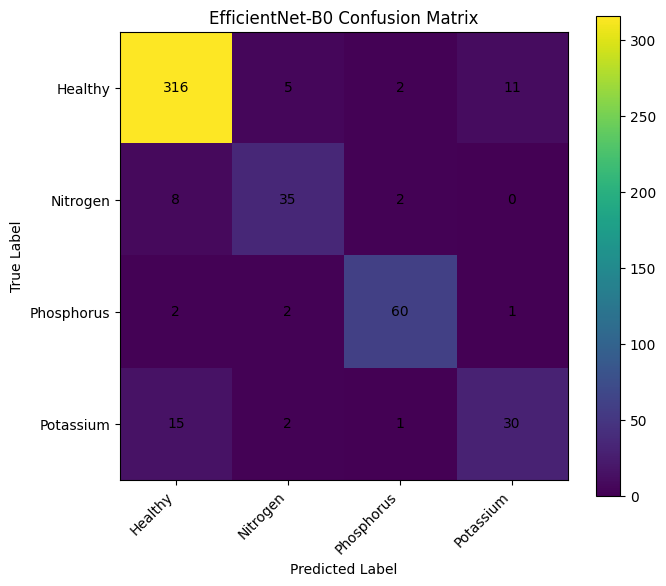

In [ ]:
# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 6))

plt.imshow(cm, interpolation="nearest")

plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Class labels
tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    class_names
)

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

### Test 5 Random images

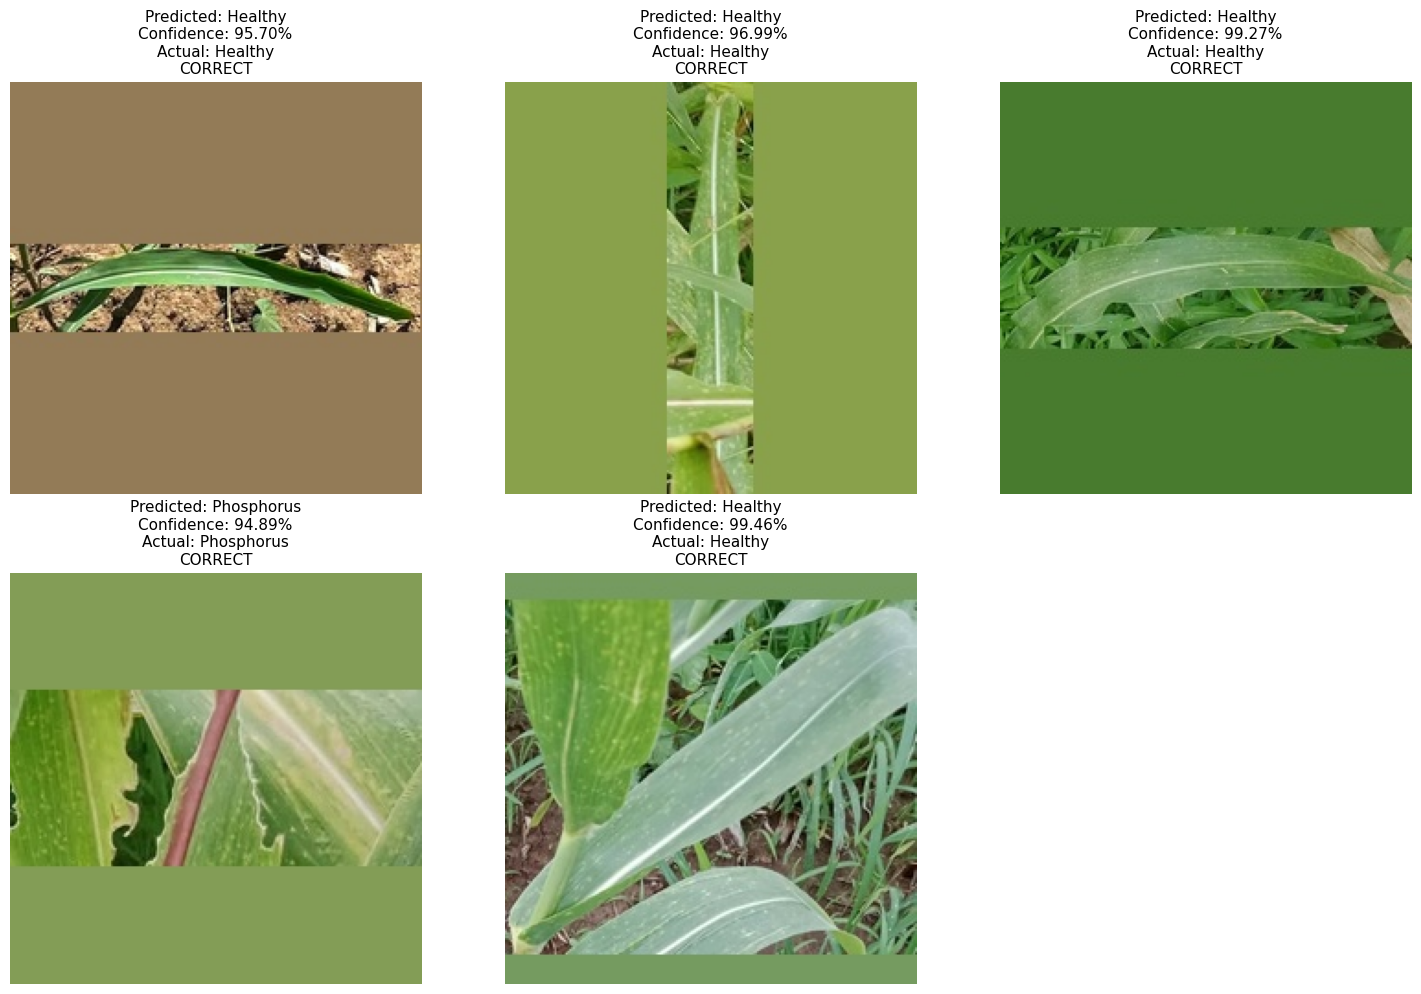

In [ ]:
# ============================================================
# RANDOM 5 TEST IMAGES - MODEL PREDICTION
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

random.seed(42)

TEST_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Test_resize224x224px"

class_names = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]

# ------------------------------------------------------------
# GET ALL TEST IMAGES
# ------------------------------------------------------------

image_paths = []

for class_name in class_names:
    class_folder = os.path.join(TEST_DIR, class_name)

    for filename in os.listdir(class_folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(
                (os.path.join(class_folder, filename), class_name)
            )

# Randomly select 5 images
selected_images = random.sample(image_paths, 5)

# ------------------------------------------------------------
# LOAD IMAGES AND PREDICT
# ------------------------------------------------------------

images = []
actual_labels = []

for image_path, actual_class in selected_images:

    img = Image.open(image_path).convert("RGB")

    # Already 224x224, but make sure
    img = img.resize((224, 224))

    img_array = np.array(img)

    images.append(img_array)
    actual_labels.append(actual_class)

# Convert to batch
X = np.array(images)

# Get predictions
predictions = best_model.predict(X, verbose=0)

predicted_indices = np.argmax(predictions, axis=1)
predicted_labels = [
    class_names[i] for i in predicted_indices
]

confidences = np.max(predictions, axis=1) * 100

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

plt.figure(figsize=(15, 10))

for i in range(5):

    plt.subplot(2, 3, i + 1)

    plt.imshow(images[i])
    plt.axis("off")

    actual = actual_labels[i]
    predicted = predicted_labels[i]
    confidence = confidences[i]

    # Check whether prediction is correct
    if actual == predicted:
        result = "CORRECT"
    else:
        result = "INCORRECT"

    plt.title(
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.2f}%\n"
        f"Actual: {actual}\n"
        f"{result}",
        fontsize=11
    )

plt.tight_layout()
plt.show()

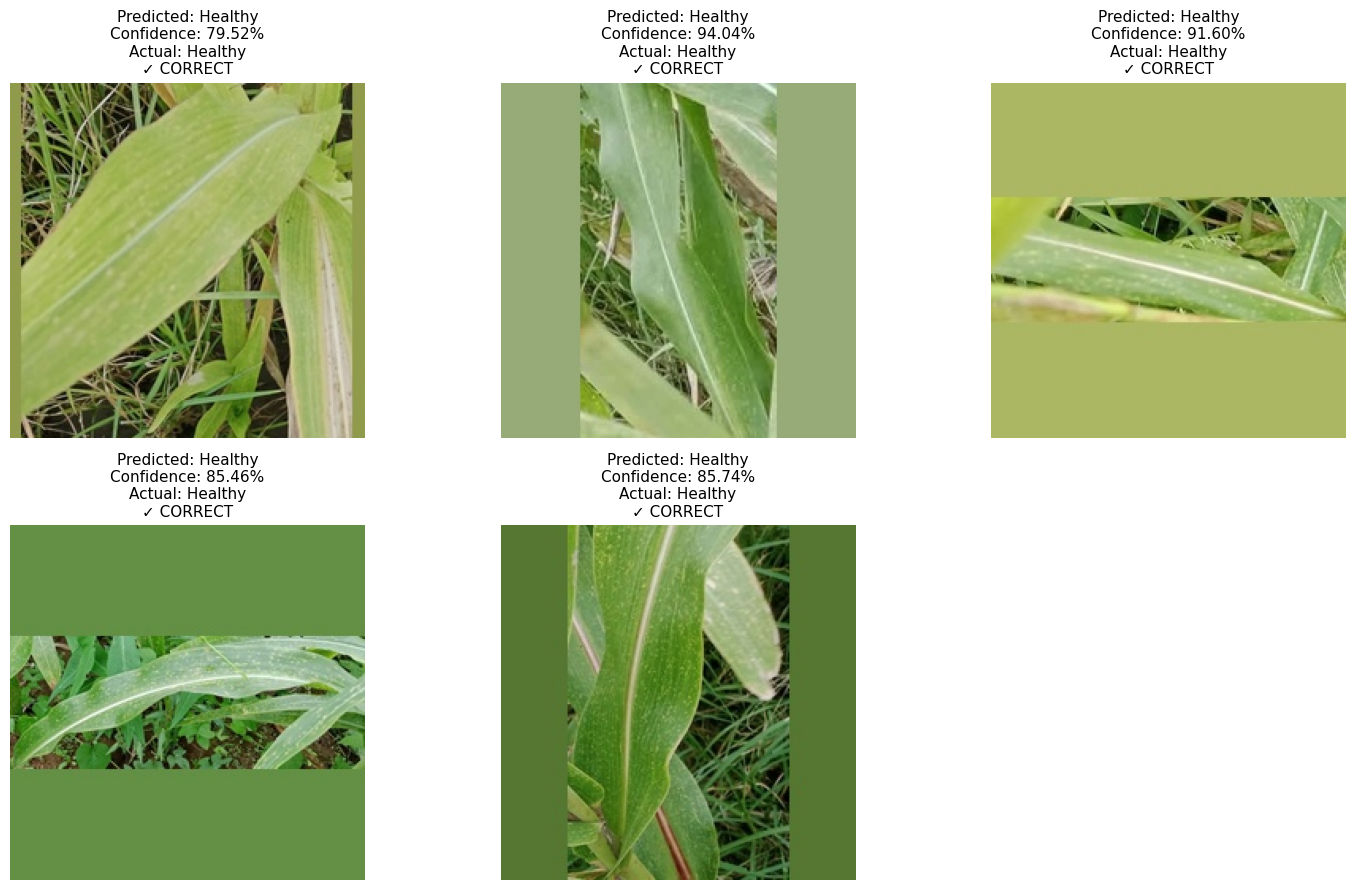

In [ ]:
# ============================================================
# RANDOM 5 TEST IMAGES - NEW IMAGES EVERY RUN
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

TEST_DIR = "/content/drive/MyDrive/CornLeafTraining/Classification_Test_resize224x224px"

class_names = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]

# ------------------------------------------------------------
# GET ALL TEST IMAGES
# ------------------------------------------------------------

image_paths = []

for class_name in class_names:
    class_folder = os.path.join(TEST_DIR, class_name)

    for filename in os.listdir(class_folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(
                (os.path.join(class_folder, filename), class_name)
            )

# ------------------------------------------------------------
# RANDOMLY SELECT 5 DIFFERENT IMAGES EVERY RUN
# ------------------------------------------------------------

selected_images = random.sample(image_paths, 5)

# ------------------------------------------------------------
# LOAD IMAGES
# ------------------------------------------------------------

images = []
actual_labels = []

for image_path, actual_class in selected_images:

    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))

    images.append(np.array(img))
    actual_labels.append(actual_class)

# Convert to batch
X = np.array(images)

# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

predictions = best_model.predict(X, verbose=0)

predicted_indices = np.argmax(predictions, axis=1)

predicted_labels = [
    class_names[i]
    for i in predicted_indices
]

confidences = np.max(predictions, axis=1) * 100

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(15, 9))

for i in range(5):

    plt.subplot(2, 3, i + 1)

    plt.imshow(images[i])
    plt.axis("off")

    actual = actual_labels[i]
    predicted = predicted_labels[i]
    confidence = confidences[i]

    if actual == predicted:
        result = "✓ CORRECT"
    else:
        result = "✗ INCORRECT"

    plt.title(
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.2f}%\n"
        f"Actual: {actual}\n"
        f"{result}",
        fontsize=11
    )

plt.tight_layout()
plt.show()

![separator1](https://i.imgur.com/ZUWYTii.png)
## Combined YOLO for Detection and EfficienetB0 for Classifcation
![separator1](https://i.imgur.com/ZUWYTii.png)

YOLOv8 model loaded successfully! ✅
EfficientNet-B0 model loaded successfully! ✅


Saving sample_leaf2.png to sample_leaf2.png


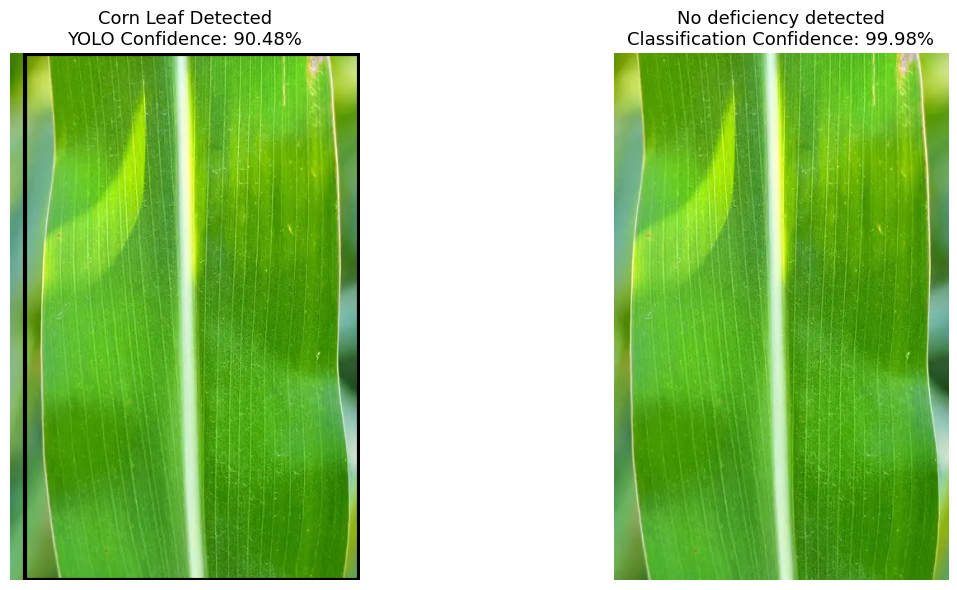


FINAL CLASSIFICATION RESULT
YOLO Detection       : Corn Leaf
YOLO Confidence      : 90.48%
Predicted Class      : Healthy
Classification       : No deficiency detected
Classifier Confidence: 99.98%

Class Probabilities:
Healthy     : 99.98%
Nitrogen    : 0.00%
Phosphorus  : 0.01%
Potassium   : 0.01%


In [ ]:
# ============================================================
# YOLOv8 → CORN LEAF DETECTION → EFFICIENTNET-B0 CLASSIFICATION
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

try:
    from ultralytics import YOLO
except ImportError:
    !pip install -q ultralytics
    from ultralytics import YOLO

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files


# ============================================================
# MODEL PATHS
# ============================================================

YOLO_MODEL_PATH = (
    "/content/drive/MyDrive/CornLeafTraining/"
    "Final_Data4/YOLOv8_Training10/"
    "yolov8s_cornleaf_training_experiment3/"
    "weights/best.pt"
)

EFFICIENTNET_MODEL_PATH = (
    "/content/drive/MyDrive/CornLeafTraining/"
    "efficientnetb0_finetuned_best.keras"
)


# ============================================================
# LOAD YOLOv8 MODEL
# ============================================================

yolo_model = YOLO(YOLO_MODEL_PATH)

print("YOLOv8 model loaded successfully! ✅")


# ============================================================
# LOAD EFFICIENTNET-B0 MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    EFFICIENTNET_MODEL_PATH
)

print("EfficientNet-B0 model loaded successfully! ✅")


# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]


# ============================================================
# RESULT LABELS
# ============================================================

result_labels = {
    "Healthy": "No deficiency detected",
    "Nitrogen": "Nitrogen deficiency detected",
    "Phosphorus": "Phosphorus deficiency detected",
    "Potassium": "Potassium deficiency detected"
}


# ============================================================
# UPLOAD IMAGE
# ============================================================

uploaded = files.upload()

image_path = next(iter(uploaded))

original_img = Image.open(
    image_path
).convert("RGB")


# ============================================================
# YOLOv8 CORN LEAF DETECTION
# ============================================================

results = yolo_model.predict(
    source=np.array(original_img),
    conf=0.25,
    verbose=False
)

result = results[0]


# ============================================================
# CHECK IF CORN LEAF WAS DETECTED
# ============================================================

if result.boxes is None or len(result.boxes) == 0:

    print("\n" + "=" * 60)
    print("DETECTION RESULT")
    print("=" * 60)

    print("❌ No corn leaf detected.")
    print(
        "Please upload an image containing "
        "a visible corn leaf."
    )

else:

    # ========================================================
    # GET HIGHEST-CONFIDENCE CORN LEAF
    # ========================================================

    boxes = result.boxes

    confidences = (
        boxes.conf.cpu().numpy()
    )

    best_detection_index = np.argmax(
        confidences
    )

    best_box = (
        boxes.xyxy[
            best_detection_index
        ]
        .cpu()
        .numpy()
    )

    yolo_confidence = (
        confidences[
            best_detection_index
        ] * 100
    )


    # ========================================================
    # CROP CORN LEAF
    # ========================================================

    x1, y1, x2, y2 = (
        best_box.astype(int)
    )

    # Keep coordinates inside image
    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(
        original_img.width,
        x2
    )

    y2 = min(
        original_img.height,
        y2
    )

    cropped_leaf = original_img.crop(
        (x1, y1, x2, y2)
    )


    # ========================================================
    # RESIZE CROP TO 224 × 224
    # ========================================================

    leaf_resized = cropped_leaf.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    leaf_array = np.array(
        leaf_resized
    )

    # Add batch dimension
    X = np.expand_dims(
        leaf_array,
        axis=0
    )


    # ========================================================
    # EFFICIENTNET-B0 CLASSIFICATION
    # ========================================================

    prediction = best_model.predict(
        X,
        verbose=0
    )

    predicted_index = np.argmax(
        prediction[0]
    )

    predicted_class = class_names[
        predicted_index
    ]

    classification_confidence = (
        prediction[0][predicted_index] * 100
    )


    # ========================================================
    # DISPLAY RESULTS
    # ========================================================

    plt.figure(figsize=(14, 6))


    # --------------------------------------------------------
    # ORIGINAL IMAGE + YOLO BOUNDING BOX
    # --------------------------------------------------------

    plt.subplot(1, 2, 1)

    plt.imshow(original_img)

    rectangle = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=3
    )

    plt.gca().add_patch(
        rectangle
    )

    plt.title(
        f"Corn Leaf Detected\n"
        f"YOLO Confidence: "
        f"{yolo_confidence:.2f}%",
        fontsize=13
    )

    plt.axis("off")


    # --------------------------------------------------------
    # CROPPED CORN LEAF
    # --------------------------------------------------------

    plt.subplot(1, 2, 2)

    plt.imshow(cropped_leaf)

    plt.title(
        f"{result_labels[predicted_class]}\n"
        f"Classification Confidence: "
        f"{classification_confidence:.2f}%",
        fontsize=13
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()


    # ========================================================
    # FINAL RESULT
    # ========================================================

    print("\n" + "=" * 60)
    print("FINAL CLASSIFICATION RESULT")
    print("=" * 60)

    print(
        f"YOLO Detection       : Corn Leaf"
    )

    print(
        f"YOLO Confidence      : "
        f"{yolo_confidence:.2f}%"
    )

    print(
        f"Predicted Class      : "
        f"{predicted_class}"
    )

    print(
        f"Classification       : "
        f"{result_labels[predicted_class]}"
    )

    print(
        f"Classifier Confidence: "
        f"{classification_confidence:.2f}%"
    )


    # ========================================================
    # CLASS PROBABILITIES
    # ========================================================

    print("\nClass Probabilities:")

    for class_name, probability in zip(
        class_names,
        prediction[0]
    ):

        print(
            f"{class_name:12s}: "
            f"{probability * 100:.2f}%"
        )

YOLOv8 model loaded successfully! ✅
EfficientNet-B0 model loaded successfully! ✅


Saving leaf_0001.jpg to leaf_0001.jpg


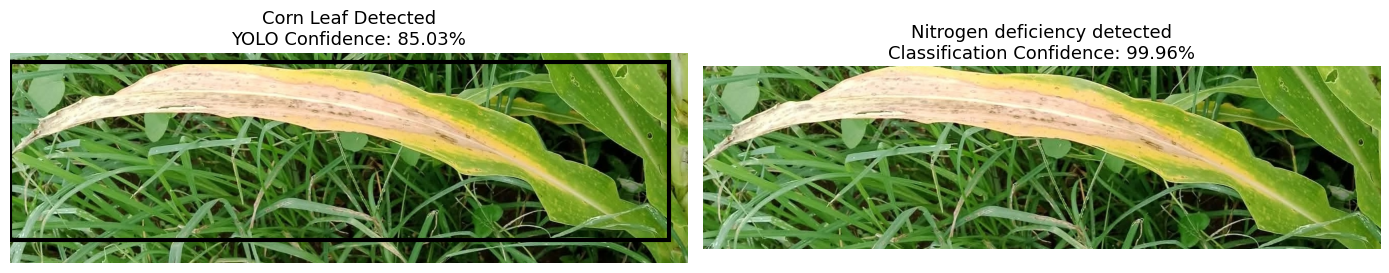


FINAL CLASSIFICATION RESULT
YOLO Detection       : Corn Leaf
YOLO Confidence      : 85.03%
Predicted Class      : Nitrogen
Classification       : Nitrogen deficiency detected
Classifier Confidence: 99.96%

Class Probabilities:
Healthy     : 0.03%
Nitrogen    : 99.96%
Phosphorus  : 0.00%
Potassium   : 0.01%


In [ ]:
# ============================================================
# YOLOv8 → CORN LEAF DETECTION → EFFICIENTNET-B0 CLASSIFICATION
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

try:
    from ultralytics import YOLO
except ImportError:
    !pip install -q ultralytics
    from ultralytics import YOLO

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files


# ============================================================
# MODEL PATHS
# ============================================================

YOLO_MODEL_PATH = (
    "/content/drive/MyDrive/CornLeafTraining/Final_Data4/YOLOv8_Training10/yolov8s_cornleaf_training_experiment1/weights/best.pt"
)

EFFICIENTNET_MODEL_PATH = (
    "/content/drive/MyDrive/CornLeafTraining/"
    "efficientnetb0_finetuned_best.keras"
)


# ============================================================
# LOAD YOLOv8 MODEL
# ============================================================

yolo_model = YOLO(YOLO_MODEL_PATH)

print("YOLOv8 model loaded successfully! ✅")


# ============================================================
# LOAD EFFICIENTNET-B0 MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    EFFICIENTNET_MODEL_PATH
)

print("EfficientNet-B0 model loaded successfully! ✅")


# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]


# ============================================================
# RESULT LABELS
# ============================================================

result_labels = {
    "Healthy": "No deficiency detected",
    "Nitrogen": "Nitrogen deficiency detected",
    "Phosphorus": "Phosphorus deficiency detected",
    "Potassium": "Potassium deficiency detected"
}


# ============================================================
# UPLOAD IMAGE
# ============================================================

uploaded = files.upload()

image_path = next(iter(uploaded))

original_img = Image.open(
    image_path
).convert("RGB")


# ============================================================
# YOLOv8 CORN LEAF DETECTION
# ============================================================

results = yolo_model.predict(
    source=np.array(original_img),
    conf=0.25,
    verbose=False
)

result = results[0]


# ============================================================
# CHECK IF CORN LEAF WAS DETECTED
# ============================================================

if result.boxes is None or len(result.boxes) == 0:

    print("\n" + "=" * 60)
    print("DETECTION RESULT")
    print("=" * 60)

    print("❌ No corn leaf detected.")
    print(
        "Please upload an image containing "
        "a visible corn leaf."
    )

else:

    # ========================================================
    # GET HIGHEST-CONFIDENCE CORN LEAF
    # ========================================================

    boxes = result.boxes

    confidences = (
        boxes.conf.cpu().numpy()
    )

    best_detection_index = np.argmax(
        confidences
    )

    best_box = (
        boxes.xyxy[
            best_detection_index
        ]
        .cpu()
        .numpy()
    )

    yolo_confidence = (
        confidences[
            best_detection_index
        ] * 100
    )


    # ========================================================
    # CROP CORN LEAF
    # ========================================================

    x1, y1, x2, y2 = (
        best_box.astype(int)
    )

    # Keep coordinates inside image
    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(
        original_img.width,
        x2
    )

    y2 = min(
        original_img.height,
        y2
    )

    cropped_leaf = original_img.crop(
        (x1, y1, x2, y2)
    )


    # ========================================================
    # RESIZE CROP TO 224 × 224
    # ========================================================

    leaf_resized = cropped_leaf.resize(
        (224, 224),
        Image.Resampling.LANCZOS
    )

    leaf_array = np.array(
        leaf_resized
    )

    # Add batch dimension
    X = np.expand_dims(
        leaf_array,
        axis=0
    )


    # ========================================================
    # EFFICIENTNET-B0 CLASSIFICATION
    # ========================================================

    prediction = best_model.predict(
        X,
        verbose=0
    )

    predicted_index = np.argmax(
        prediction[0]
    )

    predicted_class = class_names[
        predicted_index
    ]

    classification_confidence = (
        prediction[0][predicted_index] * 100
    )


    # ========================================================
    # DISPLAY RESULTS
    # ========================================================

    plt.figure(figsize=(14, 6))


    # --------------------------------------------------------
    # ORIGINAL IMAGE + YOLO BOUNDING BOX
    # --------------------------------------------------------

    plt.subplot(1, 2, 1)

    plt.imshow(original_img)

    rectangle = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=3
    )

    plt.gca().add_patch(
        rectangle
    )

    plt.title(
        f"Corn Leaf Detected\n"
        f"YOLO Confidence: "
        f"{yolo_confidence:.2f}%",
        fontsize=13
    )

    plt.axis("off")


    # --------------------------------------------------------
    # CROPPED CORN LEAF
    # --------------------------------------------------------

    plt.subplot(1, 2, 2)

    plt.imshow(cropped_leaf)

    plt.title(
        f"{result_labels[predicted_class]}\n"
        f"Classification Confidence: "
        f"{classification_confidence:.2f}%",
        fontsize=13
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()


    # ========================================================
    # FINAL RESULT
    # ========================================================

    print("\n" + "=" * 60)
    print("FINAL CLASSIFICATION RESULT")
    print("=" * 60)

    print(
        f"YOLO Detection       : Corn Leaf"
    )

    print(
        f"YOLO Confidence      : "
        f"{yolo_confidence:.2f}%"
    )

    print(
        f"Predicted Class      : "
        f"{predicted_class}"
    )

    print(
        f"Classification       : "
        f"{result_labels[predicted_class]}"
    )

    print(
        f"Classifier Confidence: "
        f"{classification_confidence:.2f}%"
    )


    # ========================================================
    # CLASS PROBABILITIES
    # ========================================================

    print("\nClass Probabilities:")

    for class_name, probability in zip(
        class_names,
        prediction[0]
    ):

        print(
            f"{class_name:12s}: "
            f"{probability * 100:.2f}%"
        )

YOLOv8 model loaded successfully! ✅
EfficientNet-B0 model loaded successfully! ✅


Saving leaf_0031.jpg to leaf_0031.jpg

YOLOv8 DETECTION RESULT
Total corn leaves detected: 1


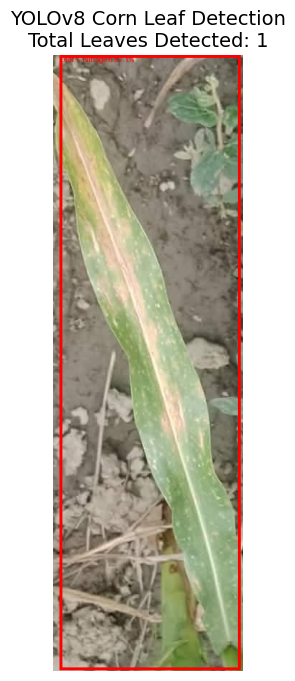

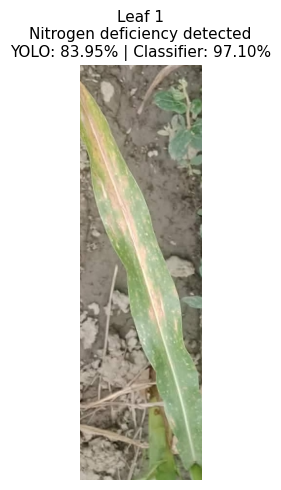


FINAL CORN LEAF ANALYSIS RESULTS
Total Leaves Detected: 1

Leaf 1
YOLO Detection       : Corn Leaf
YOLO Confidence      : 83.95%
Predicted Class      : Nitrogen
Classification       : Nitrogen deficiency detected
Classifier Confidence: 97.10%
Class Probabilities:
  Healthy     : 0.91%
  Nitrogen    : 97.10%
  Phosphorus  : 0.04%
  Potassium   : 1.95%

ANALYSIS COMPLETE


In [ ]:
# ============================================================
# YOLOv8 → CORN LEAF DETECTION → EFFICIENTNET-B0 CLASSIFICATION
# MULTIPLE DETECTIONS VERSION
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

try:
    from ultralytics import YOLO
except ImportError:
    !pip install -q ultralytics
    from ultralytics import YOLO

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from google.colab import files


# ============================================================
# MODEL PATHS
# ============================================================

YOLO_MODEL_PATH = (
    "/content/drive/MyDrive/CornLeafTraining/"
    "Final_Data4/YOLOv8_Training10/"
    "yolov8s_cornleaf_training_experiment1/"
    "weights/best.pt"
)

EFFICIENTNET_MODEL_PATH = (
    "/content/drive/MyDrive/CornLeafTraining/"
    "efficientnetb0_finetuned_best.keras"
)


# ============================================================
# LOAD YOLOv8 MODEL
# ============================================================

yolo_model = YOLO(YOLO_MODEL_PATH)

print("YOLOv8 model loaded successfully! ✅")


# ============================================================
# LOAD EFFICIENTNET-B0 MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    EFFICIENTNET_MODEL_PATH
)

print("EfficientNet-B0 model loaded successfully! ✅")


# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]


# ============================================================
# RESULT LABELS
# ============================================================

result_labels = {
    "Healthy": "No deficiency detected",
    "Nitrogen": "Nitrogen deficiency detected",
    "Phosphorus": "Phosphorus deficiency detected",
    "Potassium": "Potassium deficiency detected"
}


# ============================================================
# IMAGE PREPROCESSING FUNCTION
# ============================================================
# This matches the training preprocessing:
#
# 1. Preserve aspect ratio
# 2. No stretching
# 3. No cropping
# 4. Add minimum padding
# 5. Resize final image to exactly 224 × 224
# 6. Use LANCZOS interpolation
# ============================================================

def preprocess_leaf(image, target_size=(224, 224)):

    target_width, target_height = target_size

    original_width, original_height = image.size

    # --------------------------------------------------------
    # Calculate scale while preserving aspect ratio
    # --------------------------------------------------------

    scale = min(
        target_width / original_width,
        target_height / original_height
    )

    new_width = max(
        1,
        int(round(original_width * scale))
    )

    new_height = max(
        1,
        int(round(original_height * scale))
    )

    # --------------------------------------------------------
    # Resize while preserving aspect ratio
    # --------------------------------------------------------

    resized = image.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # --------------------------------------------------------
    # Determine padding
    # --------------------------------------------------------

    pad_left = (target_width - new_width) // 2
    pad_top = (target_height - new_height) // 2

    pad_right = (
        target_width
        - new_width
        - pad_left
    )

    pad_bottom = (
        target_height
        - new_height
        - pad_top
    )

    # --------------------------------------------------------
    # Calculate padding color from image edges
    # --------------------------------------------------------

    image_array = np.array(image)

    edge_pixels = np.concatenate([
        image_array[0, :, :],
        image_array[-1, :, :],
        image_array[:, 0, :],
        image_array[:, -1, :]
    ], axis=0)

    padding_color = tuple(
        np.median(
            edge_pixels,
            axis=0
        ).astype(np.uint8)
    )

    # --------------------------------------------------------
    # Create padded image
    # --------------------------------------------------------

    padded = Image.new(
        "RGB",
        (target_width, target_height),
        padding_color
    )

    padded.paste(
        resized,
        (pad_left, pad_top)
    )

    return padded


# ============================================================
# UPLOAD IMAGE
# ============================================================

uploaded = files.upload()

image_path = next(iter(uploaded))

original_img = Image.open(
    image_path
).convert("RGB")


# ============================================================
# YOLOv8 CORN LEAF DETECTION
# ============================================================

results = yolo_model.predict(
    source=np.array(original_img),
    conf=0.25,
    verbose=False
)

result = results[0]


# ============================================================
# CHECK IF CORN LEAVES WERE DETECTED
# ============================================================

if result.boxes is None or len(result.boxes) == 0:

    print("\n" + "=" * 60)
    print("DETECTION RESULT")
    print("=" * 60)

    print("❌ No corn leaf detected.")

    print(
        "Please upload an image containing "
        "visible corn leaves."
    )


else:

    # ========================================================
    # GET ALL DETECTIONS
    # ========================================================

    boxes = result.boxes

    total_detections = len(boxes)

    print("\n" + "=" * 60)
    print("YOLOv8 DETECTION RESULT")
    print("=" * 60)

    print(
        f"Total corn leaves detected: "
        f"{total_detections}"
    )


    # ========================================================
    # STORAGE FOR ALL CROPPED LEAVES
    # ========================================================

    cropped_leaves = []

    yolo_confidences = []

    bounding_boxes = []


    # ========================================================
    # CROP EVERY DETECTED CORN LEAF
    # ========================================================

    for i in range(total_detections):

        # ----------------------------------------------------
        # Get bounding box
        # ----------------------------------------------------

        box = (
            boxes.xyxy[i]
            .cpu()
            .numpy()
        )

        x1, y1, x2, y2 = (
            box.astype(int)
        )

        # ----------------------------------------------------
        # Keep coordinates inside image
        # ----------------------------------------------------

        x1 = max(
            0,
            x1
        )

        y1 = max(
            0,
            y1
        )

        x2 = min(
            original_img.width,
            x2
        )

        y2 = min(
            original_img.height,
            y2
        )

        # ----------------------------------------------------
        # YOLO confidence
        # ----------------------------------------------------

        confidence = (
            boxes.conf[i]
            .cpu()
            .item()
        )

        yolo_confidences.append(
            confidence * 100
        )

        bounding_boxes.append(
            (x1, y1, x2, y2)
        )

        # ----------------------------------------------------
        # Crop leaf
        # ----------------------------------------------------

        cropped_leaf = original_img.crop(
            (x1, y1, x2, y2)
        )

        cropped_leaves.append(
            cropped_leaf
        )


    # ========================================================
    # PREPROCESS ALL CROPS
    # ========================================================

    processed_images = []

    for cropped_leaf in cropped_leaves:

        processed_leaf = preprocess_leaf(
            cropped_leaf,
            target_size=(224, 224)
        )

        processed_images.append(
            np.array(processed_leaf)
        )


    # ========================================================
    # CREATE BATCH
    # ========================================================

    X = np.stack(
        processed_images,
        axis=0
    )


    # ========================================================
    # EFFICIENTNET-B0 CLASSIFICATION
    # ========================================================
    # ALL detected leaves are classified here.
    # ========================================================

    predictions = best_model.predict(
        X,
        verbose=0
    )


    # ========================================================
    # STORE CLASSIFICATION RESULTS
    # ========================================================

    predicted_classes = []

    classification_confidences = []


    for prediction in predictions:

        predicted_index = np.argmax(
            prediction
        )

        predicted_class = class_names[
            predicted_index
        ]

        classification_confidence = (
            prediction[predicted_index] * 100
        )

        predicted_classes.append(
            predicted_class
        )

        classification_confidences.append(
            classification_confidence
        )


    # ========================================================
    # DISPLAY ORIGINAL IMAGE WITH ALL BOXES
    # ========================================================

    display_img = original_img.copy()

    draw = ImageDraw.Draw(
        display_img
    )


    for i, (
        box,
        yolo_conf,
        predicted_class,
        class_conf
    ) in enumerate(
        zip(
            bounding_boxes,
            yolo_confidences,
            predicted_classes,
            classification_confidences
        ),
        start=1
    ):

        x1, y1, x2, y2 = box

        # ----------------------------------------------------
        # Draw bounding box
        # ----------------------------------------------------

        draw.rectangle(
            [x1, y1, x2, y2],
            outline="red",
            width=4
        )

        # ----------------------------------------------------
        # Label
        # ----------------------------------------------------

        label = (
            f"Leaf {i}: "
            f"{predicted_class} "
            f"{class_conf:.1f}%"
        )

        draw.text(
            (x1, max(0, y1 - 20)),
            label,
            fill="red"
        )


    # ========================================================
    # DISPLAY DETECTION IMAGE
    # ========================================================

    plt.figure(
        figsize=(12, 8)
    )

    plt.imshow(
        display_img
    )

    plt.title(
        f"YOLOv8 Corn Leaf Detection\n"
        f"Total Leaves Detected: "
        f"{total_detections}",
        fontsize=14
    )

    plt.axis("off")

    plt.show()


    # ========================================================
    # DISPLAY EACH CROPPED LEAF
    # ========================================================

    columns = 3

    rows = int(
        np.ceil(
            total_detections / columns
        )
    )

    plt.figure(
        figsize=(
            15,
            rows * 5
        )
    )


    for i in range(
        total_detections
    ):

        plt.subplot(
            rows,
            columns,
            i + 1
        )

        plt.imshow(
            cropped_leaves[i]
        )

        predicted_class = (
            predicted_classes[i]
        )

        class_confidence = (
            classification_confidences[i]
        )

        yolo_confidence = (
            yolo_confidences[i]
        )

        plt.title(
            f"Leaf {i + 1}\n"
            f"{result_labels[predicted_class]}\n"
            f"YOLO: {yolo_confidence:.2f}% | "
            f"Classifier: {class_confidence:.2f}%",
            fontsize=11
        )

        plt.axis("off")


    plt.tight_layout()
    plt.show()


    # ========================================================
    # FINAL RESULTS
    # ========================================================

    print("\n" + "=" * 70)
    print("FINAL CORN LEAF ANALYSIS RESULTS")
    print("=" * 70)

    print(
        f"Total Leaves Detected: "
        f"{total_detections}"
    )


    # ========================================================
    # PRINT RESULT FOR EVERY LEAF
    # ========================================================

    for i in range(
        total_detections
    ):

        predicted_class = (
            predicted_classes[i]
        )

        print(
            f"\nLeaf {i + 1}"
        )

        print(
            f"YOLO Detection       : "
            f"Corn Leaf"
        )

        print(
            f"YOLO Confidence      : "
            f"{yolo_confidences[i]:.2f}%"
        )

        print(
            f"Predicted Class      : "
            f"{predicted_class}"
        )

        print(
            f"Classification       : "
            f"{result_labels[predicted_class]}"
        )

        print(
            f"Classifier Confidence: "
            f"{classification_confidences[i]:.2f}%"
        )


        # ----------------------------------------------------
        # Class probabilities for this leaf
        # ----------------------------------------------------

        print(
            "Class Probabilities:"
        )

        for class_name, probability in zip(
            class_names,
            predictions[i]
        ):

            print(
                f"  {class_name:12s}: "
                f"{probability * 100:.2f}%"
            )


    print("\n" + "=" * 70)
    print("ANALYSIS COMPLETE")
    print("=" * 70)

YOLOv8 model loaded successfully! ✅
EfficientNet-B0 model loaded successfully! ✅


Saving leaf_0090.jpg to leaf_0090 (1).jpg

YOLOv8 DETECTION RESULT
Total corn leaves detected: 3


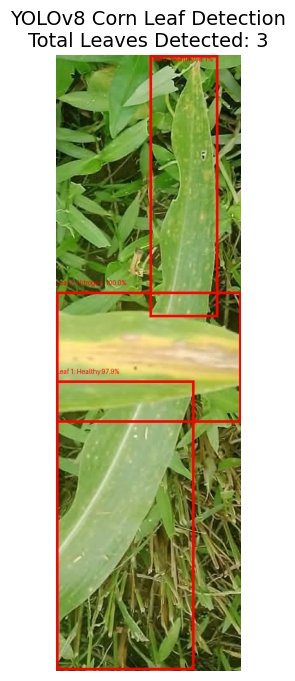

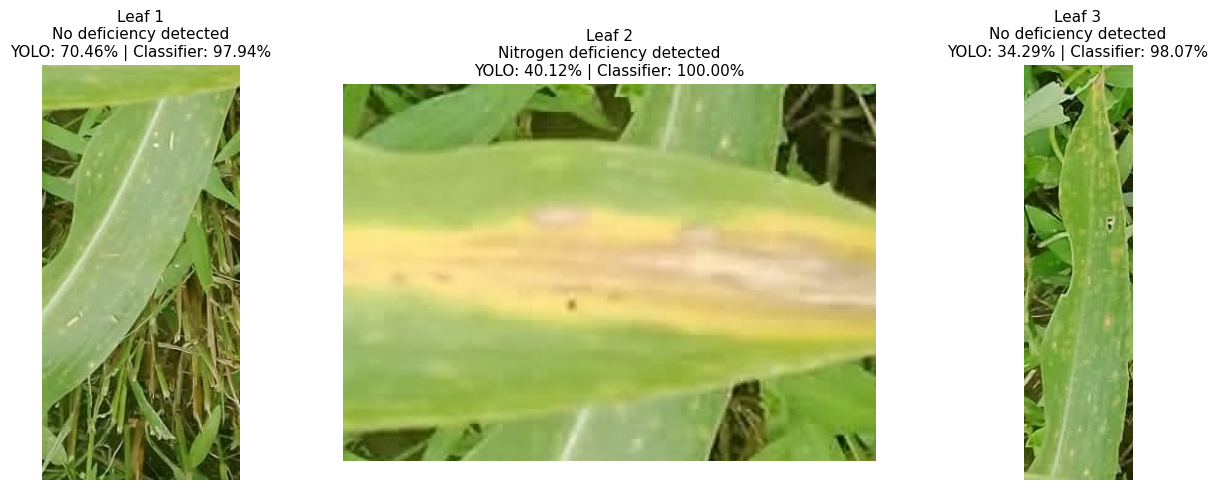


FINAL CORN LEAF ANALYSIS RESULTS
Total Leaves Detected: 3

Leaf 1
YOLO Detection       : Corn Leaf
YOLO Confidence      : 70.46%
Predicted Class      : Healthy
Classification       : No deficiency detected
Classifier Confidence: 97.94%
Class Probabilities:
  Healthy     : 97.94%
  Nitrogen    : 0.90%
  Phosphorus  : 0.01%
  Potassium   : 1.15%

Leaf 2
YOLO Detection       : Corn Leaf
YOLO Confidence      : 40.12%
Predicted Class      : Nitrogen
Classification       : Nitrogen deficiency detected
Classifier Confidence: 100.00%
Class Probabilities:
  Healthy     : 0.00%
  Nitrogen    : 100.00%
  Phosphorus  : 0.00%
  Potassium   : 0.00%

Leaf 3
YOLO Detection       : Corn Leaf
YOLO Confidence      : 34.29%
Predicted Class      : Healthy
Classification       : No deficiency detected
Classifier Confidence: 98.07%
Class Probabilities:
  Healthy     : 98.07%
  Nitrogen    : 1.52%
  Phosphorus  : 0.00%
  Potassium   : 0.41%

ANALYSIS COMPLETE


In [ ]:
# ============================================================
# YOLOv8 → CORN LEAF DETECTION → EFFICIENTNET-B0 CLASSIFICATION
# MULTIPLE DETECTIONS VERSION
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

try:
    from ultralytics import YOLO
except ImportError:
    !pip install -q ultralytics
    from ultralytics import YOLO

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from google.colab import files


# ============================================================
# MODEL PATHS
# ============================================================

YOLO_MODEL_PATH = (
    "/content/drive/MyDrive/CornLeafTraining/"
    "Final_Data4/YOLOv8_Training10/"
    "yolov8s_cornleaf_training_experiment1/"
    "weights/best.pt"
)

EFFICIENTNET_MODEL_PATH = (
    "/content/drive/MyDrive/CornLeafTraining/"
    "efficientnetb0_finetuned_best.keras"
)


# ============================================================
# LOAD YOLOv8 MODEL
# ============================================================

yolo_model = YOLO(YOLO_MODEL_PATH)

print("YOLOv8 model loaded successfully! ✅")


# ============================================================
# LOAD EFFICIENTNET-B0 MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    EFFICIENTNET_MODEL_PATH
)

print("EfficientNet-B0 model loaded successfully! ✅")


# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "Healthy",
    "Nitrogen",
    "Phosphorus",
    "Potassium"
]


# ============================================================
# RESULT LABELS
# ============================================================

result_labels = {
    "Healthy": "No deficiency detected",
    "Nitrogen": "Nitrogen deficiency detected",
    "Phosphorus": "Phosphorus deficiency detected",
    "Potassium": "Potassium deficiency detected"
}


# ============================================================
# IMAGE PREPROCESSING FUNCTION
# ============================================================
# This matches the training preprocessing:
#
# 1. Preserve aspect ratio
# 2. No stretching
# 3. No cropping
# 4. Add minimum padding
# 5. Resize final image to exactly 224 × 224
# 6. Use LANCZOS interpolation
# ============================================================

def preprocess_leaf(image, target_size=(224, 224)):

    target_width, target_height = target_size

    original_width, original_height = image.size

    # --------------------------------------------------------
    # Calculate scale while preserving aspect ratio
    # --------------------------------------------------------

    scale = min(
        target_width / original_width,
        target_height / original_height
    )

    new_width = max(
        1,
        int(round(original_width * scale))
    )

    new_height = max(
        1,
        int(round(original_height * scale))
    )

    # --------------------------------------------------------
    # Resize while preserving aspect ratio
    # --------------------------------------------------------

    resized = image.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # --------------------------------------------------------
    # Determine padding
    # --------------------------------------------------------

    pad_left = (target_width - new_width) // 2
    pad_top = (target_height - new_height) // 2

    pad_right = (
        target_width
        - new_width
        - pad_left
    )

    pad_bottom = (
        target_height
        - new_height
        - pad_top
    )

    # --------------------------------------------------------
    # Calculate padding color from image edges
    # --------------------------------------------------------

    image_array = np.array(image)

    edge_pixels = np.concatenate([
        image_array[0, :, :],
        image_array[-1, :, :],
        image_array[:, 0, :],
        image_array[:, -1, :]
    ], axis=0)

    padding_color = tuple(
        np.median(
            edge_pixels,
            axis=0
        ).astype(np.uint8)
    )

    # --------------------------------------------------------
    # Create padded image
    # --------------------------------------------------------

    padded = Image.new(
        "RGB",
        (target_width, target_height),
        padding_color
    )

    padded.paste(
        resized,
        (pad_left, pad_top)
    )

    return padded


# ============================================================
# UPLOAD IMAGE
# ============================================================

uploaded = files.upload()

image_path = next(iter(uploaded))

original_img = Image.open(
    image_path
).convert("RGB")


# ============================================================
# YOLOv8 CORN LEAF DETECTION
# ============================================================

results = yolo_model.predict(
    source=np.array(original_img),
    conf=0.25,
    verbose=False
)

result = results[0]


# ============================================================
# CHECK IF CORN LEAVES WERE DETECTED
# ============================================================

if result.boxes is None or len(result.boxes) == 0:

    print("\n" + "=" * 60)
    print("DETECTION RESULT")
    print("=" * 60)

    print("❌ No corn leaf detected.")

    print(
        "Please upload an image containing "
        "visible corn leaves."
    )


else:

    # ========================================================
    # GET ALL DETECTIONS
    # ========================================================

    boxes = result.boxes

    total_detections = len(boxes)

    print("\n" + "=" * 60)
    print("YOLOv8 DETECTION RESULT")
    print("=" * 60)

    print(
        f"Total corn leaves detected: "
        f"{total_detections}"
    )


    # ========================================================
    # STORAGE FOR ALL CROPPED LEAVES
    # ========================================================

    cropped_leaves = []

    yolo_confidences = []

    bounding_boxes = []


    # ========================================================
    # CROP EVERY DETECTED CORN LEAF
    # ========================================================

    for i in range(total_detections):

        # ----------------------------------------------------
        # Get bounding box
        # ----------------------------------------------------

        box = (
            boxes.xyxy[i]
            .cpu()
            .numpy()
        )

        x1, y1, x2, y2 = (
            box.astype(int)
        )

        # ----------------------------------------------------
        # Keep coordinates inside image
        # ----------------------------------------------------

        x1 = max(
            0,
            x1
        )

        y1 = max(
            0,
            y1
        )

        x2 = min(
            original_img.width,
            x2
        )

        y2 = min(
            original_img.height,
            y2
        )

        # ----------------------------------------------------
        # YOLO confidence
        # ----------------------------------------------------

        confidence = (
            boxes.conf[i]
            .cpu()
            .item()
        )

        yolo_confidences.append(
            confidence * 100
        )

        bounding_boxes.append(
            (x1, y1, x2, y2)
        )

        # ----------------------------------------------------
        # Crop leaf
        # ----------------------------------------------------

        cropped_leaf = original_img.crop(
            (x1, y1, x2, y2)
        )

        cropped_leaves.append(
            cropped_leaf
        )


    # ========================================================
    # PREPROCESS ALL CROPS
    # ========================================================

    processed_images = []

    for cropped_leaf in cropped_leaves:

        processed_leaf = preprocess_leaf(
            cropped_leaf,
            target_size=(224, 224)
        )

        processed_images.append(
            np.array(processed_leaf)
        )


    # ========================================================
    # CREATE BATCH
    # ========================================================

    X = np.stack(
        processed_images,
        axis=0
    )


    # ========================================================
    # EFFICIENTNET-B0 CLASSIFICATION
    # ========================================================
    # ALL detected leaves are classified here.
    # ========================================================

    predictions = best_model.predict(
        X,
        verbose=0
    )


    # ========================================================
    # STORE CLASSIFICATION RESULTS
    # ========================================================

    predicted_classes = []

    classification_confidences = []


    for prediction in predictions:

        predicted_index = np.argmax(
            prediction
        )

        predicted_class = class_names[
            predicted_index
        ]

        classification_confidence = (
            prediction[predicted_index] * 100
        )

        predicted_classes.append(
            predicted_class
        )

        classification_confidences.append(
            classification_confidence
        )


    # ========================================================
    # DISPLAY ORIGINAL IMAGE WITH ALL BOXES
    # ========================================================

    display_img = original_img.copy()

    draw = ImageDraw.Draw(
        display_img
    )


    for i, (
        box,
        yolo_conf,
        predicted_class,
        class_conf
    ) in enumerate(
        zip(
            bounding_boxes,
            yolo_confidences,
            predicted_classes,
            classification_confidences
        ),
        start=1
    ):

        x1, y1, x2, y2 = box

        # ----------------------------------------------------
        # Draw bounding box
        # ----------------------------------------------------

        draw.rectangle(
            [x1, y1, x2, y2],
            outline="red",
            width=4
        )

        # ----------------------------------------------------
        # Label
        # ----------------------------------------------------

        label = (
            f"Leaf {i}: "
            f"{predicted_class} "
            f"{class_conf:.1f}%"
        )

        draw.text(
            (x1, max(0, y1 - 20)),
            label,
            fill="red"
        )


    # ========================================================
    # DISPLAY DETECTION IMAGE
    # ========================================================

    plt.figure(
        figsize=(12, 8)
    )

    plt.imshow(
        display_img
    )

    plt.title(
        f"YOLOv8 Corn Leaf Detection\n"
        f"Total Leaves Detected: "
        f"{total_detections}",
        fontsize=14
    )

    plt.axis("off")

    plt.show()


    # ========================================================
    # DISPLAY EACH CROPPED LEAF
    # ========================================================

    columns = 3

    rows = int(
        np.ceil(
            total_detections / columns
        )
    )

    plt.figure(
        figsize=(
            15,
            rows * 5
        )
    )


    for i in range(
        total_detections
    ):

        plt.subplot(
            rows,
            columns,
            i + 1
        )

        plt.imshow(
            cropped_leaves[i]
        )

        predicted_class = (
            predicted_classes[i]
        )

        class_confidence = (
            classification_confidences[i]
        )

        yolo_confidence = (
            yolo_confidences[i]
        )

        plt.title(
            f"Leaf {i + 1}\n"
            f"{result_labels[predicted_class]}\n"
            f"YOLO: {yolo_confidence:.2f}% | "
            f"Classifier: {class_confidence:.2f}%",
            fontsize=11
        )

        plt.axis("off")


    plt.tight_layout()
    plt.show()


    # ========================================================
    # FINAL RESULTS
    # ========================================================

    print("\n" + "=" * 70)
    print("FINAL CORN LEAF ANALYSIS RESULTS")
    print("=" * 70)

    print(
        f"Total Leaves Detected: "
        f"{total_detections}"
    )


    # ========================================================
    # PRINT RESULT FOR EVERY LEAF
    # ========================================================

    for i in range(
        total_detections
    ):

        predicted_class = (
            predicted_classes[i]
        )

        print(
            f"\nLeaf {i + 1}"
        )

        print(
            f"YOLO Detection       : "
            f"Corn Leaf"
        )

        print(
            f"YOLO Confidence      : "
            f"{yolo_confidences[i]:.2f}%"
        )

        print(
            f"Predicted Class      : "
            f"{predicted_class}"
        )

        print(
            f"Classification       : "
            f"{result_labels[predicted_class]}"
        )

        print(
            f"Classifier Confidence: "
            f"{classification_confidences[i]:.2f}%"
        )


        # ----------------------------------------------------
        # Class probabilities for this leaf
        # ----------------------------------------------------

        print(
            "Class Probabilities:"
        )

        for class_name, probability in zip(
            class_names,
            predictions[i]
        ):

            print(
                f"  {class_name:12s}: "
                f"{probability * 100:.2f}%"
            )


    print("\n" + "=" * 70)
    print("ANALYSIS COMPLETE")
    print("=" * 70)